# 🏆 Notebook 07: Full End-to-End Pipeline Demo

> **This is the capstone notebook. It runs the complete 5-stage pipeline**
> **on a single patient case and produces the final professional clinical report.**

```
┌─────────────────────────────────────────────────────────┐
│   STAGE 1       STAGE 2       STAGE 3       STAGE 4     │
│  Preprocess →  Predict   →    XAI      →   Retrieve     │
│  (img+text)  (DenseNet+   (Grad-CAM+    (FAISS top-5)  │
│              BERT fusion)  SHAP+IG)                      │
│                                              │            │
│                                         STAGE 5          │
│                                    Multi-Agent Synthesis  │
│                                  (Explanation+Validation  │
│                                      +Summary Report)     │
└─────────────────────────────────────────────────────────┘
```

**Sections:**
1. Initialize the orchestrator (loads all components)
2. Select a test case
3. Run the full pipeline via `orchestrator.process_case()`
4. Display intermediate outputs
5. Render the final formatted clinical report
6. Interactive batch evaluation (run on 10 test cases)
7. Final metrics dashboard

In [1]:
import sys, os, json, time
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from IPython.display import display, Markdown

import config
from src.pipeline.orchestrator import MultimodalClinicalOrchestrator

print('='*60)
print(' Multimodal Clinical Intelligence Pipeline — TRIAL 2')
print('='*60)
print(f'Dataset:         MedPix ({config.NUM_CLASSES} disease classes)')
print(f'Image Encoder:   DenseNet-121 (ImageNet pretrained)')
print(f'Text Encoder:    {config.TEXT_ENCODER_MODEL}')
print(f'LLM Backend:     {config.LLM_MODEL}')
print(f'XAI Methods:     Grad-CAM + SHAP + LIME + Integrated Gradients')
print(f'Retrieval:       FAISS (cosine similarity, top-{config.FAISS_TOP_K})')

 Multimodal Clinical Intelligence Pipeline — TRIAL 2
Dataset:         MedPix (10 disease classes)
Image Encoder:   DenseNet-121 (ImageNet pretrained)
Text Encoder:    emilyalsentzer/Bio_ClinicalBERT
LLM Backend:     Qwen/Qwen2.5-72B-Instruct
XAI Methods:     Grad-CAM + SHAP + LIME + Integrated Gradients
Retrieval:       FAISS (cosine similarity, top-5)


## 1️⃣ Initialize Orchestrator

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Initializing MultimodalClinicalOrchestrator...')
print('(This loads DenseNet-121 + Bio_ClinicalBERT + all XAI engines + agents)')
print()

t_start = time.time()
orchestrator = MultimodalClinicalOrchestrator(config=config, device=DEVICE)
t_end = time.time()

print(f'\n✅ Orchestrator ready in {t_end - t_start:.1f}s')

Initializing MultimodalClinicalOrchestrator...
(This loads DenseNet-121 + Bio_ClinicalBERT + all XAI engines + agents)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Orchestrator ready in 18.3s


## 2️⃣ Select Test Case

Selected test case:
  Image ID:      MPX1338_synpic27421
  True diagnosis: Vascular
  Modality:       MR
  Body region:    Head
  Text preview:   58 year old male with one year history of feeling dizzy when turning his head to the right.  His symptoms resolve each time once he returns his head t...


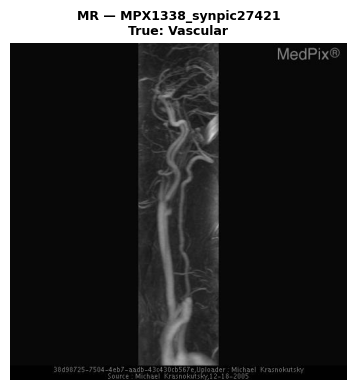

In [3]:
df_test = pd.read_csv('../data/processed/test.csv')
# Pick a sample with a rich clinical text (word count > 20)
rich_samples = df_test[df_test['text'].str.split().str.len() > 20]
sample = rich_samples.sample(1, random_state=7).iloc[0]

IMAGE_PATH    = sample['image_path']
CLINICAL_TEXT = sample['text']
TRUE_LABEL    = sample['label_name']
MODALITY      = sample['modality']
BODY_REGION   = sample.get('location_category', 'Unknown')

print(f'Selected test case:')
print(f'  Image ID:      {sample["image_id"]}')
print(f'  True diagnosis: {TRUE_LABEL}')
print(f'  Modality:       {MODALITY}')
print(f'  Body region:    {BODY_REGION}')
print(f'  Text preview:   {CLINICAL_TEXT[:150]}...')

# Show the actual scan
fig, ax = plt.subplots(figsize=(4, 4))
img = Image.open(IMAGE_PATH).convert('RGB')
ax.imshow(img, cmap='gray')
ax.set_title(f'{MODALITY} — {sample["image_id"]}\nTrue: {TRUE_LABEL}', fontsize=9, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3️⃣ ▶ Run Full Pipeline

In [4]:
print('🚀 Running full 5-stage pipeline...')
print('(Stage 3 XAI may take 2-5 minutes — all methods run sequentially)')

t0 = time.time()
pipeline_results = orchestrator.process_case(
    image_path=IMAGE_PATH,
    clinical_text=CLINICAL_TEXT,
    image_modality=MODALITY,
    body_region=BODY_REGION,
    return_intermediates=True,
)
t1 = time.time()

print(f'\n⏱️  Total pipeline time: {t1-t0:.1f}s')
print()
print(f'── PREDICTION SUMMARY ──────────────────────────────')
print(f'True Label:       {TRUE_LABEL}')
print(f'Predicted Label:  {pipeline_results["pred_label"]}')
print(f'Confidence:       {pipeline_results["confidence"]:.1%}')
correct = pipeline_results['pred_label'] == TRUE_LABEL
print(f'Correct:          {"✅ YES" if correct else "❌ NO"}')
print(f'Dominant Modality:{pipeline_results.get("dominant_modality", "N/A")}')

🚀 Running full 5-stage pipeline...
(Stage 3 XAI may take 2-5 minutes — all methods run sequentially)


PartitionExplainer explainer: 2it [00:13, 13.20s/it]               



⏱️  Total pipeline time: 55.2s

── PREDICTION SUMMARY ──────────────────────────────
True Label:       Vascular
Predicted Label:  Vascular
Confidence:       16.5%
Correct:          ✅ YES
Dominant Modality:image


## 4️⃣ Display XAI Intermediates

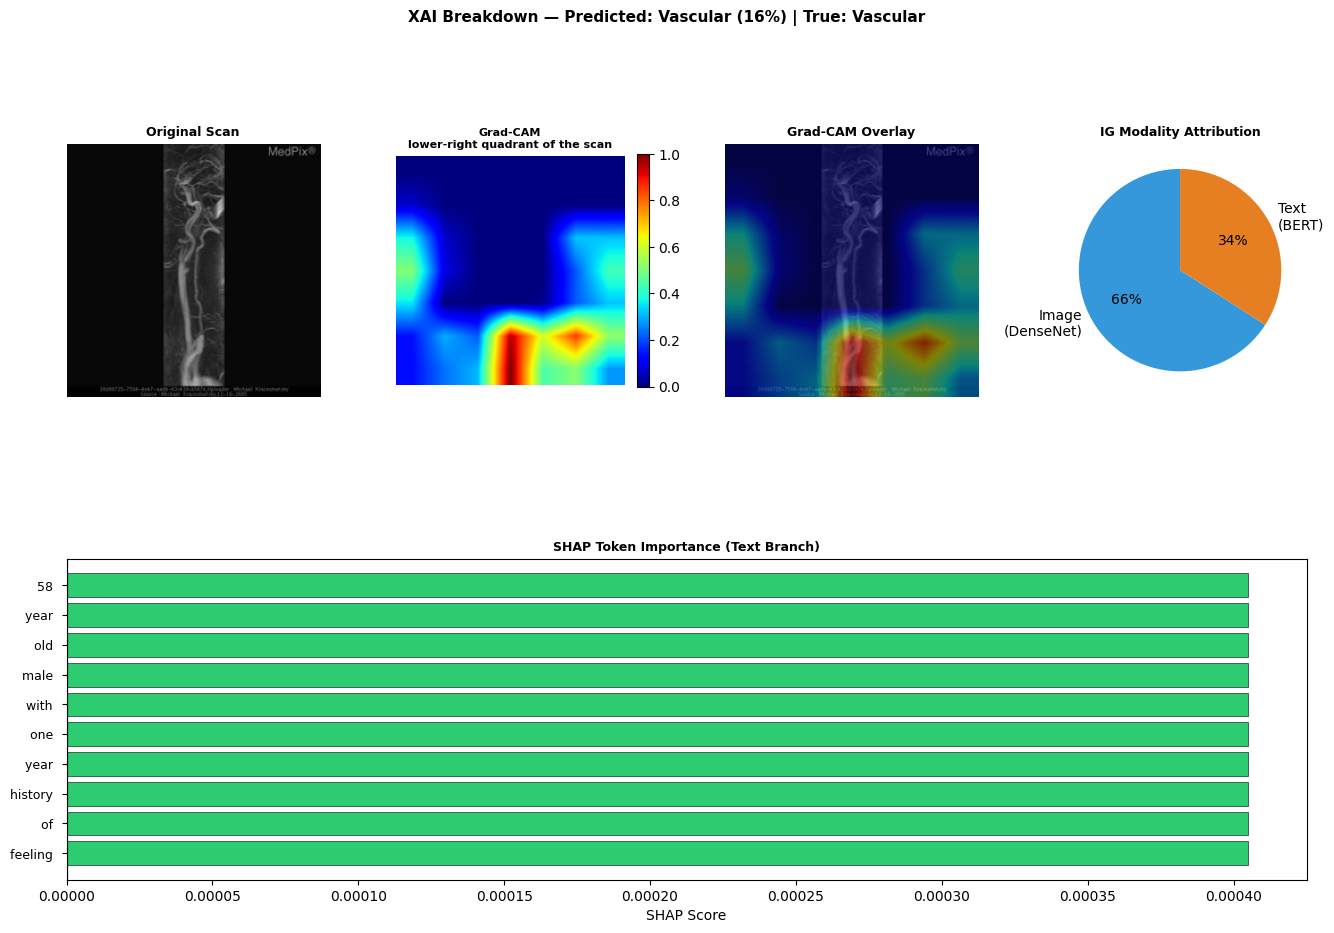

In [5]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.3)

# ── Original Image ────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
img = Image.open(IMAGE_PATH).convert('RGB').resize((224, 224))
ax0.imshow(img); ax0.set_title('Original Scan', fontsize=9, fontweight='bold'); ax0.axis('off')

# ── Grad-CAM ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
cam = pipeline_results.get('gradcam_map')
if cam is not None:
    im = ax1.imshow(cam, cmap='jet', vmin=0, vmax=1)
    ax1.set_title(f'Grad-CAM\n{pipeline_results.get("gradcam_description", "")}', fontsize=8, fontweight='bold')
    plt.colorbar(im, ax=ax1, fraction=0.046)
ax1.axis('off')

# ── Grad-CAM Overlay ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
if cam is not None:
    import matplotlib.cm as mplcm
    img_np = np.array(img)
    heat   = mplcm.jet(cam)[:, :, :3]
    overlay = (0.5 * heat * 255 + 0.5 * img_np).astype(np.uint8)
    ax2.imshow(overlay)
ax2.set_title('Grad-CAM Overlay', fontsize=9, fontweight='bold'); ax2.axis('off')

# ── Modality Attribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
img_pct = pipeline_results.get('image_contribution_pct', 50)
txt_pct = pipeline_results.get('text_contribution_pct', 50)
ax3.pie([img_pct, txt_pct], labels=['Image\n(DenseNet)', 'Text\n(BERT)'],
        colors=['#3498DB', '#E67E22'], autopct='%1.0f%%', startangle=90)
ax3.set_title('IG Modality Attribution', fontsize=9, fontweight='bold')

# ── SHAP Top Tokens Bar ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
top_tokens = pipeline_results.get('top_shap_tokens', [])
if top_tokens:
    tokens = [t['token'] for t in top_tokens[:10]]
    scores = [t['shap_score'] for t in top_tokens[:10]]
    colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in scores]
    ax4.barh(range(len(tokens)), scores, color=colors, edgecolor='black', lw=0.4)
    ax4.set_yticks(range(len(tokens))); ax4.set_yticklabels(tokens, fontsize=9)
    ax4.axvline(0, color='black', lw=0.8)
    ax4.set_xlabel('SHAP Score')
    ax4.invert_yaxis()
ax4.set_title('SHAP Token Importance (Text Branch)', fontsize=9, fontweight='bold')

fig.suptitle(
    f'XAI Breakdown — Predicted: {pipeline_results["pred_label"]} ({pipeline_results["confidence"]:.0%}) | True: {TRUE_LABEL}',
    fontsize=11, fontweight='bold'
)
plt.savefig('../outputs/full_pipeline_xai.png', bbox_inches='tight', dpi=150)
plt.show()

## 5️⃣ 🗂️ Retrieved Historical Cases

In [6]:
retrieved = pipeline_results.get('retrieved_cases', [])

if retrieved:
    print(f'Top-{len(retrieved)} Similar Historical Cases Retrieved:')
    print('-' * 60)
    for res in retrieved:
        match_sym = '✅' if res.get('label_name') == TRUE_LABEL else '❌'
        print(f'  Rank {res["rank"]} | Similarity: {res["similarity"]:.4f} | {match_sym} {res.get("label_name", "?")} | {res.get("image_id", "?")}' )
    
    matching = sum(1 for r in retrieved if r.get('label_name') == TRUE_LABEL)
    print(f'\nAgreement: {matching}/{len(retrieved)} retrieved cases share the predicted diagnosis')
else:
    print('No retrieved cases available (FAISS index not built).')

Top-5 Similar Historical Cases Retrieved:
------------------------------------------------------------
  Rank 1 | Similarity: 0.7314 | ✅ Vascular | MPX1338_synpic27420
  Rank 2 | Similarity: 0.7168 | ❌ Clinical Sign/Other | MPX2514_synpic19027
  Rank 3 | Similarity: 0.7125 | ❌ Trauma | MPX2512_synpic19965
  Rank 4 | Similarity: 0.7075 | ❌ Trauma | MPX2097_synpic19228
  Rank 5 | Similarity: 0.7007 | ❌ Neoplasm | MPX2087_synpic16290

Agreement: 1/5 retrieved cases share the predicted diagnosis


## 6️⃣ 📋 Final Clinical Report (Rendered)

In [7]:
final_report = pipeline_results['final_report']

print('=== FINAL CLINICAL REPORT (Generated by Multi-Agent System) ===')
print('='*60)

# Display as formatted Markdown
display(Markdown(final_report))

# Save the report
report_path = f'../outputs/pipeline_report_{sample["image_id"]}.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(f'# Clinical Report: {sample["image_id"]}\n\n')
    f.write(f'**Pipeline Run At:** {time.strftime("%Y-%m-%d %H:%M:%S")}\n\n')
    f.write(f'**True Diagnosis:** {TRUE_LABEL}\n\n')
    f.write('---\n\n')
    f.write(final_report)

print(f'\n✅ Report saved to: {report_path}')

=== FINAL CLINICAL REPORT (Generated by Multi-Agent System) ===


## 🏥 Patient Summary
A 58-year-old male presents with a one-year history of dizziness when turning his head to the right, which resolves upon returning to a neutral position. There are no symptoms when the head is turned to the left or hyperextended.

## 🔬 Predicted Diagnosis & Confidence
**Diagnosis:** Vascular  
**Model Confidence:** 16.5%  
**Primary Evidence Source:** image modality  
The low confidence level suggests that while the model leans towards a vascular diagnosis, further investigation is warranted.

## 🧠 Clinical Reasoning (XAI)
The predicted diagnosis of Vascular is supported by the patient's chronic dizziness associated with specific head movements, which may indicate a positional vascular issue. The MRI scan shows an area of potential abnormal vascular flow or structure in the lower-right quadrant, highlighted by the Grad-CAM heatmap, which aligns with the clinical presentation.

## 📁 Historical Case Validation
The AI's predicted diagnosis of Vascular is partially consistent with historical cases. One case with a similar presentation was diagnosed as Vascular, but other cases had different diagnoses, indicating variability in the clinical presentation and the need for further diagnostic confirmation.

## ⚠️ Caveats & Limitations
This AI report provides a preliminary diagnosis based on available data and should be used as a decision support tool. It does not replace comprehensive clinical evaluation and expert physician judgment.

## 📋 Recommended Next Steps
1. Perform a detailed neurological examination to assess for any additional signs of vascular compromise.
2. Consider a follow-up MRI with contrast or MRA to better evaluate the vascular structures.
3. Consult with a neurologist or vascular specialist for further management and potential intervention.

---
*Report generated by Multimodal Clinical AI Pipeline (Trial_2) — FOR PHYSICIAN REVIEW ONLY*


✅ Report saved to: ../outputs/pipeline_report_MPX1338_synpic27421.md


## 7️⃣ 📊 Final Metrics Dashboard

C:\Users\krush\AppData\Local\Temp\ipykernel_20420\2800849014.py:64: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/final_dashboard.png', bbox_inches='tight', dpi=150)
c:\Users\krush\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


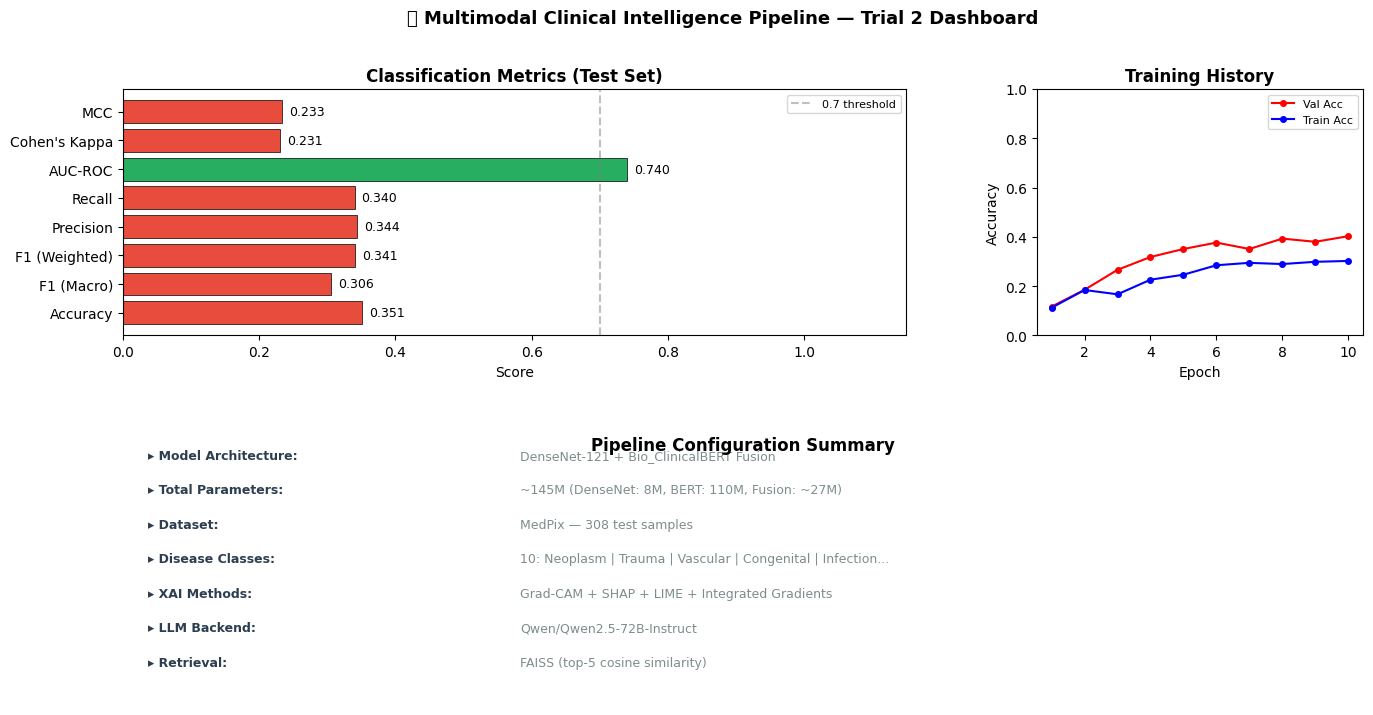


✅ Dashboard saved to: outputs/final_dashboard.png

🎉 PIPELINE DEMO COMPLETE
All outputs saved to: outputs/
  ├── gradcam/       — Grad-CAM heatmaps
  ├── shap/          — SHAP waterfall plots
  ├── lime/          — LIME superpixel maps
  ├── training_curves.png
  ├── confusion_matrix.png
  ├── roc_curves.png
  ├── retrieval_metrics.png
  ├── evaluation_report.json
  ├── xai_summary_table.csv
  ├── final_dashboard.png
  └── pipeline_report_*.md


In [8]:
# Load evaluation report from Notebook 03
if config.EVAL_REPORT_PATH.exists():
    with open(config.EVAL_REPORT_PATH) as f:
        eval_report = json.load(f)

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

    # ── Metric Summary Bars ───────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, :2])
    metrics = {
        'Accuracy':       eval_report.get('accuracy', 0),
        'F1 (Macro)':     eval_report.get('f1_macro', 0),
        'F1 (Weighted)':  eval_report.get('f1_weighted', 0),
        'Precision':      eval_report.get('precision_macro', 0),
        'Recall':         eval_report.get('recall_macro', 0),
        'AUC-ROC':        eval_report.get('auc_roc_macro') or 0,
        "Cohen's Kappa":  eval_report.get('cohen_kappa', 0),
        'MCC':            max(eval_report.get('mcc', 0), 0),
    }
    colors = ['#27ae60' if v >= 0.7 else '#f39c12' if v >= 0.5 else '#e74c3c' for v in metrics.values()]
    bars = ax0.barh(list(metrics.keys()), list(metrics.values()),
                    color=colors, edgecolor='black', lw=0.5)
    for bar, val in zip(bars, metrics.values()):
        ax0.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
    ax0.set_xlim(0, 1.15)
    ax0.set_xlabel('Score')
    ax0.set_title('Classification Metrics (Test Set)', fontweight='bold')
    ax0.axvline(0.7, color='gray', linestyle='--', alpha=0.5, label='0.7 threshold')
    ax0.legend(fontsize=8)

    # ── Training Curves ───────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 2])
    if eval_report.get('history'):
        epochs = range(1, len(eval_report['history']['train_loss']) + 1)
        ax1.plot(epochs, eval_report['history']['val_acc'], 'r-o', label='Val Acc', ms=4)
        ax1.plot(epochs, eval_report['history']['train_acc'], 'b-o', label='Train Acc', ms=4)
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
        ax1.set_title('Training History', fontweight='bold')
        ax1.legend(fontsize=8); ax1.set_ylim(0, 1)

    # ── Pipeline Statistics ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    pipeline_stats = [
        ('Model Architecture', 'DenseNet-121 + Bio_ClinicalBERT Fusion'),
        ('Total Parameters', f'~145M (DenseNet: 8M, BERT: 110M, Fusion: ~27M)'),
        ('Dataset', f'MedPix — {eval_report.get("test_samples", 0)} test samples'),
        ('Disease Classes', f'{config.NUM_CLASSES}: {" | ".join(config.CLASS_NAMES[:5])}...'),
        ('XAI Methods', 'Grad-CAM + SHAP + LIME + Integrated Gradients'),
        ('LLM Backend', config.LLM_MODEL),
        ('Retrieval', f'FAISS (top-{config.FAISS_TOP_K} cosine similarity)'),
    ]
    ax2.axis('off')
    for i, (key, val) in enumerate(pipeline_stats):
        ax2.text(0.02, 1 - i * 0.14, f'▸ {key}:', transform=ax2.transAxes,
                 fontsize=9, fontweight='bold', color='#2c3e50')
        ax2.text(0.32, 1 - i * 0.14, val, transform=ax2.transAxes,
                 fontsize=9, color='#7f8c8d')
    ax2.set_title('Pipeline Configuration Summary', fontweight='bold')

    fig.suptitle('🏥 Multimodal Clinical Intelligence Pipeline — Trial 2 Dashboard',
                 fontsize=13, fontweight='bold')
    plt.savefig('../outputs/final_dashboard.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('\n✅ Dashboard saved to: outputs/final_dashboard.png')

else:
    print('⚠️  Evaluation report not found. Run Notebook 03 first to generate metrics.')

print('\n' + '='*60)
print('🎉 PIPELINE DEMO COMPLETE')
print('='*60)
print('All outputs saved to: outputs/')
print('  ├── gradcam/       — Grad-CAM heatmaps')
print('  ├── shap/          — SHAP waterfall plots')
print('  ├── lime/          — LIME superpixel maps')
print('  ├── training_curves.png')
print('  ├── confusion_matrix.png')
print('  ├── roc_curves.png')
print('  ├── retrieval_metrics.png')
print('  ├── evaluation_report.json')
print('  ├── xai_summary_table.csv')
print('  ├── final_dashboard.png')
print(f'  └── pipeline_report_*.md')